# Compare Three Attention Maps

This notebook renders a clean 3-panel comparison for one layer/head:

1. baseline
2. residual-based
3. value-based

It reads local `plot_bundle.json` files from `drawing/attn_matrix/source/...` and writes the figure to `drawing/attn_matrix/outputs/...`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

ATTN_MATRIX_DIR = Path("/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/drawing/attn_matrix")
SOURCE_DIR = ATTN_MATRIX_DIR / "source/qwen3-4b/layer19"
OUTPUT_DIR = Path("/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ATTN_MATRIX_DIR, SOURCE_DIR, OUTPUT_DIR


(PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/drawing/attn_matrix'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/drawing/attn_matrix/source/qwen3-4b/layer19'),
 PosixPath('/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19'))

In [2]:
# Edit these if you want another head/layer later.
LAYER_TAG = "layer19"
HEAD_TAG = "h6"
FIGSIZE = (13.5, 4.6)
DPI = 240
TITLE_PREFIX = "Qwen3-4B Layer 19 Head 6"
MAIN_CMAP = "viridis"
DELTA_CMAP = "coolwarm"

# Main-map display options.
MASK_DIAGONAL_IN_MAIN = False
SCALE_MAIN_BY_OFFDIAG = True
DIAG_BAD_COLOR = '#d9d9d9'
SHOW_TOKEN_LABELS = False
MINMAX_FMT = '.4f'

ATTN_BUNDLE = SOURCE_DIR / "attn" / f"{HEAD_TAG}_plot_bundle.json"
XSA_BUNDLE = SOURCE_DIR / "xsa" / f"{HEAD_TAG}_plot_bundle.json"
OUT_PATH = OUTPUT_DIR / f"{HEAD_TAG}_three_map_compare.pdf"

ATTN_BUNDLE, XSA_BUNDLE, OUT_PATH


(PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/drawing/attn_matrix/source/qwen3-4b/layer19/attn/h6_plot_bundle.json'),
 PosixPath('/Users/bytedance/Documents/GitHub/MMEBarch/representation-analysis/drawing/attn_matrix/source/qwen3-4b/layer19/xsa/h6_plot_bundle.json'),
 PosixPath('/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19/h6_three_map_compare.pdf'))

In [3]:
def load_bundle(path: Path):
    raw = json.loads(path.read_text(encoding="utf-8"))
    out = {}
    for key, value in raw.items():
        if isinstance(value, list):
            out[key] = np.asarray(value, dtype=object if key == "token_labels" else float)
        else:
            out[key] = np.asarray(value)
    return out

attn = load_bundle(ATTN_BUNDLE)
xsa = load_bundle(XSA_BUNDLE)
sorted(attn.keys()), sorted(xsa.keys())[:8]

(['baseline_attention_layer',
  'effective_delta_layer',
  'panel1_baseline',
  'panel2_effective_compare',
  'panel3_effective_delta',
  'panel4_diag',
  'panel4_offdiag_sum',
  'panel4_total_sum',
  'raw_x_removal_attention_layer',
  'raw_x_removal_mean',
  'raw_x_removal_selected',
  'token_labels'],
 ['baseline_attention_layer',
  'effective_delta_layer',
  'panel1_flip_head_baseline',
  'panel2_flip_head_effective_compare',
  'panel2_flip_head_raw_xsa',
  'panel3_flip_head_effective_delta',
  'panel4_effective_diag',
  'panel4_effective_offdiag_sum'])

In [4]:
labels = [str(x) for x in attn["token_labels"].tolist()]

baseline = np.asarray(attn["panel1_baseline"], dtype=float)
residual = np.asarray(attn["panel2_effective_compare"], dtype=float)
value_based = np.asarray(xsa["panel2_flip_head_effective_compare"], dtype=float)

def _lower_triangle_values(arr, *, include_diag=True):
    arr = np.asarray(arr, dtype=float)
    k = 0 if include_diag else -1
    mask = np.tril(np.ones_like(arr, dtype=bool), k=k)
    return arr[mask]

if SCALE_MAIN_BY_OFFDIAG:
    pooled = np.concatenate([
        _lower_triangle_values(baseline, include_diag=False),
        _lower_triangle_values(residual, include_diag=False),
        _lower_triangle_values(value_based, include_diag=False),
    ])
else:
    pooled = np.concatenate([
        _lower_triangle_values(baseline, include_diag=True),
        _lower_triangle_values(residual, include_diag=True),
        _lower_triangle_values(value_based, include_diag=True),
    ])

shared_vmax = float(np.max(pooled))
shared_vmin = float(np.min(pooled))
shared_vmax, shared_vmin


(0.90625, 0.00433349609375)

In [5]:
from matplotlib.patches import Rectangle

def overlay_diagonal_boxes(ax, n: int):
    for i in range(n):
        ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1.0, 1.0, fill=False, edgecolor='black', linewidth=1.0, alpha=0.85))
        ax.add_patch(Rectangle((i - 0.47, i - 0.47), 0.94, 0.94, fill=False, edgecolor='white', linewidth=0.8, alpha=0.9))

TITLE_FONTSIZE = 16
MINMAX_LABEL_FONTSIZE = 16
MINMAX_LABEL_PAD = 0.42


def plot_triangular(ax, matrix, title, labels, vmin, vmax, cmap=None, *, mask_diagonal=False):
    arr = np.asarray(matrix, dtype=float)
    upper_mask = np.triu(np.ones_like(arr, dtype=bool), k=1)
    full_mask = upper_mask.copy()
    if mask_diagonal:
        full_mask |= np.eye(arr.shape[0], dtype=bool)
    arr = np.ma.array(arr, mask=full_mask)
    cmap_name = MAIN_CMAP if cmap is None else cmap
    cmap_obj = plt.get_cmap(cmap_name).copy()
    cmap_obj.set_bad(color=DIAG_BAD_COLOR)
    im = ax.imshow(arr, cmap=cmap_obj, aspect='auto', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=8)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    if SHOW_TOKEN_LABELS:
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.set_yticklabels(labels, fontsize=6)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.tick_params(length=0)
    overlay_diagonal_boxes(ax, len(labels))
    visible_vals = arr.compressed() if np.ma.isMaskedArray(arr) else arr.ravel()
    ax.text(
        0.99,
        0.99,
        f'max={visible_vals.max():{MINMAX_FMT}}\nmin={visible_vals.min():{MINMAX_FMT}}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=MINMAX_LABEL_FONTSIZE,
        color='black',
        bbox=dict(boxstyle=f'round,pad={MINMAX_LABEL_PAD}', facecolor='white', alpha=0.75, linewidth=0.3),
    )
    return im


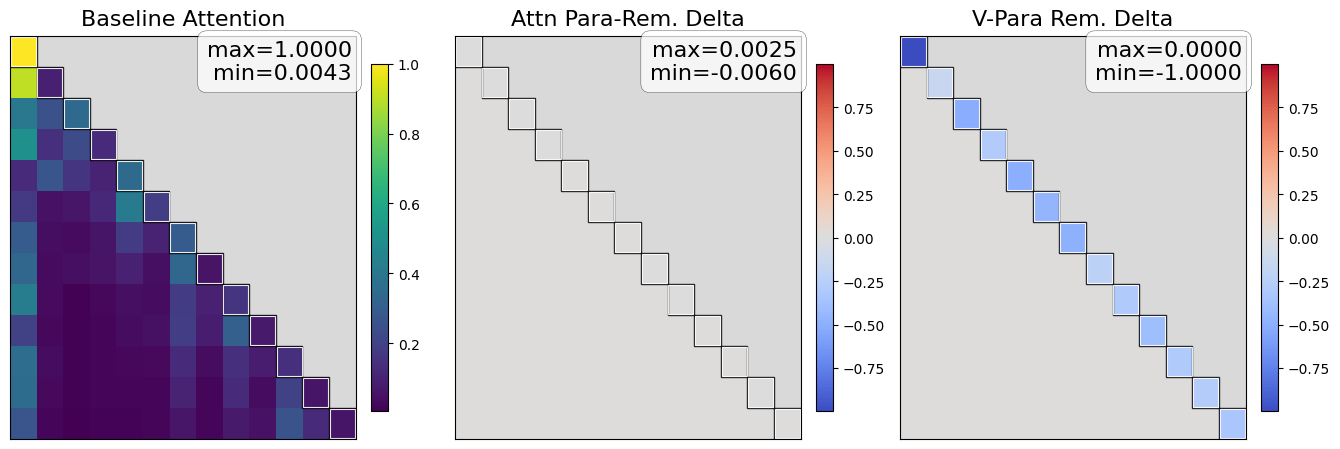

saved -> /Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19/h6_three_map_compare.pdf


In [6]:
baseline_diag = np.diag(baseline)
residual_diag = np.diag(residual)
value_diag = np.diag(value_based)

residual_delta_diag = residual_diag - baseline_diag
value_delta_diag = value_diag - baseline_diag

residual_delta_mat = np.diag(residual_delta_diag)
value_delta_mat = np.diag(value_delta_diag)

delta_abs = float(max(np.abs(residual_delta_mat).max(), np.abs(value_delta_mat).max()))
baseline_vmax = float(np.max(_lower_triangle_values(baseline, include_diag=True)))
baseline_vmin = float(np.min(_lower_triangle_values(baseline, include_diag=True)))

titles = [
    "Baseline Attention",
    "Attn Para-Rem. Delta",
    "V-Para Rem. Delta",
]

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

im0 = plot_triangular(
    axes[0],
    baseline,
    titles[0],
    labels,
    baseline_vmin,
    baseline_vmax,
    cmap=MAIN_CMAP,
    mask_diagonal=False,
)
im1 = plot_triangular(
    axes[1],
    residual_delta_mat,
    titles[1],
    labels,
    -delta_abs,
    delta_abs,
    cmap=DELTA_CMAP,
    mask_diagonal=False,
)
im2 = plot_triangular(
    axes[2],
    value_delta_mat,
    titles[2],
    labels,
    -delta_abs,
    delta_abs,
    cmap=DELTA_CMAP,
    mask_diagonal=False,
)

for ax, im in zip(axes, [im0, im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=DPI, bbox_inches='tight')
plt.show()
print(f"saved -> {OUT_PATH}")


In [7]:
# Optional: inspect the three arrays numerically
print("baseline shape:", baseline.shape)
print("residual shape:", residual.shape)
print("value_based shape:", value_based.shape)

baseline shape: (13, 13)
residual shape: (13, 13)
value_based shape: (13, 13)


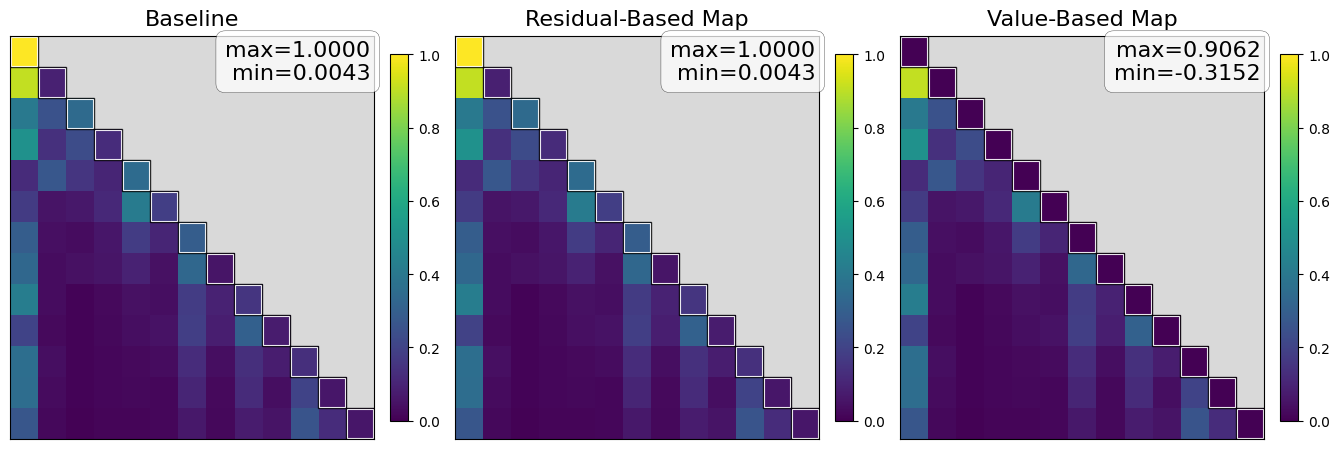

saved -> /Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19/h6_raw_three_maps_clipped_at_zero.pdf


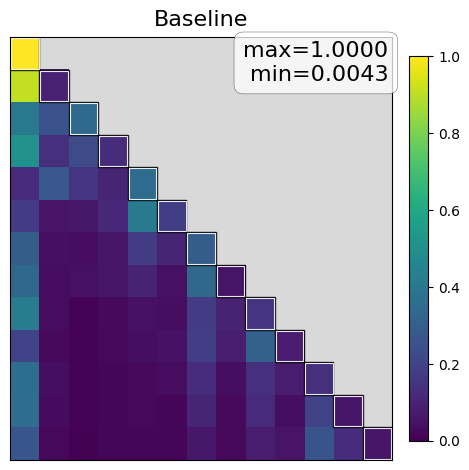

saved -> /Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19/h6_baseline_map.png


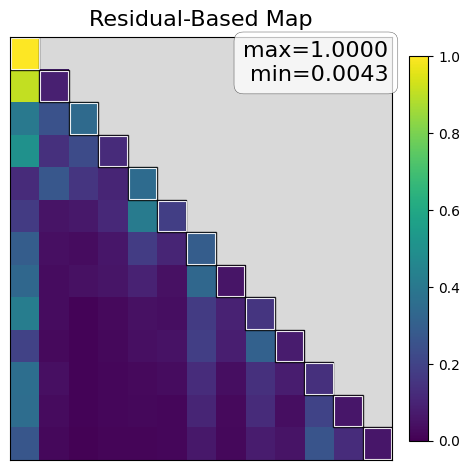

In [ ]:
# Optional: plot the three raw/effective attention maps directly, with display clipped at 0.
# This is useful when you want to inspect the full maps instead of baseline + diagonal-delta views.

raw_baseline = np.asarray(baseline, dtype=float)
raw_residual = np.asarray(residual, dtype=float)
raw_value = np.asarray(value_based, dtype=float)

raw_shared_vmax = float(max(raw_baseline.max(), raw_residual.max(), raw_value.max()))
raw_shared_vmin = 0.0
raw_out_path = OUTPUT_DIR / f"{HEAD_TAG}_raw_three_maps_clipped_at_zero.pdf"

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

im0 = plot_triangular(
    axes[0],
    raw_baseline,
    "Baseline",
    labels,
    raw_shared_vmin,
    raw_shared_vmax,
    cmap=MAIN_CMAP,
    mask_diagonal=False,
)
im1 = plot_triangular(
    axes[1],
    raw_residual,
    "Residual-Based Map",
    labels,
    raw_shared_vmin,
    raw_shared_vmax,
    cmap=MAIN_CMAP,
    mask_diagonal=False,
)
im2 = plot_triangular(
    axes[2],
    raw_value,
    "Value-Based Map",
    labels,
    raw_shared_vmin,
    raw_shared_vmax,
    cmap=MAIN_CMAP,
    mask_diagonal=False,
)

for ax, im in zip(axes, [im0, im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(raw_out_path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f"saved -> {raw_out_path}")

single_specs = [
    (raw_baseline, "Baseline", OUTPUT_DIR / f"{HEAD_TAG}_baseline_map.png"),
    (raw_residual, "Residual-Based Map", OUTPUT_DIR / f"{HEAD_TAG}_residual_based_map.png"),
    (raw_value, "Value-Based Map", OUTPUT_DIR / f"{HEAD_TAG}_value_based_map.png"),
]

for arr, title, out_path in single_specs:
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    im = plot_triangular(
        ax,
        arr,
        title,
        labels,
        raw_shared_vmin,
        raw_shared_vmax,
        cmap=MAIN_CMAP,
        mask_diagonal=False,
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(out_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"saved -> {out_path}")


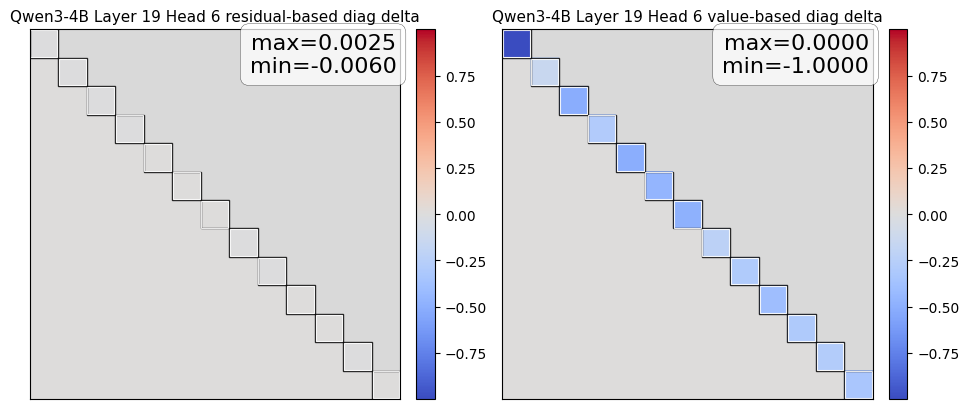

saved -> /Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/attn_matrix/outputs/qwen3-4b/layer19/h6_diag_delta_heatmaps.pdf
residual_delta_diag = [-3.42726707e-05 -5.98797202e-03 -1.87841058e-03 -2.86322832e-03
  2.53364444e-03  2.42051482e-03  7.25239515e-04 -1.18006393e-03
 -2.48238444e-04  1.73256546e-03  4.00543213e-05 -4.75674868e-04
  2.42069364e-04]
value_delta_diag = [-0.99999982 -0.14554095 -0.5091995  -0.28442633 -0.50089777 -0.45652112
 -0.49117967 -0.22382824 -0.29235554 -0.39084232 -0.30395103 -0.27694747
 -0.33090761]


In [ ]:
baseline_diag = np.diag(baseline)
residual_diag = np.diag(residual)
value_diag = np.diag(value_based)

residual_delta_diag = residual_diag - baseline_diag
value_delta_diag = value_diag - baseline_diag

residual_delta_mat = np.diag(residual_delta_diag)
value_delta_mat = np.diag(value_delta_diag)

delta_abs = float(max(np.abs(residual_delta_mat).max(), np.abs(value_delta_mat).max()))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))

im0 = plot_triangular(axes[0], residual_delta_mat, f"{TITLE_PREFIX} residual-based diag delta", labels, -delta_abs, delta_abs, cmap=DELTA_CMAP)
im1 = plot_triangular(axes[1], value_delta_mat, f"{TITLE_PREFIX} value-based diag delta", labels, -delta_abs, delta_abs, cmap=DELTA_CMAP)

for ax, im in zip(axes, [im0, im1]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
diag_out_path = OUTPUT_DIR / f"{HEAD_TAG}_diag_delta_heatmaps.pdf"
fig.savefig(diag_out_path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f"saved -> {diag_out_path}")
print('residual_delta_diag =', residual_delta_diag)
print('value_delta_diag =', value_delta_diag)